In [37]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [4]:
# metadata: https://fgdl.org/zips/metadata/xml/noise_barriers_apr23.xml
barriers = gpd.read_file("../../data/florida/noise_barriers/noise_barriers_apr23.gdb")
barriers

/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(


,FHWA_ID_19,FHWA_ID,FPN_NO,FM_ID,ROADWAY,FED_ROUTE,APPROX_LOC,FDOT_DISTR,TYPE,FED_STREF,...,MGRS,GOOGLEMAP,GCID,DESCRIPT,FLAG,UPDATE_DAY,FGDLAQDATE,AUTOID,SHAPE_Length,geometry
0,0,0,,406143-1,93470800,SR 91 / Turnpike Mainline,SR 91 FROM N OF LAKE WORTH RD TO N OF JUPITER-...,TURNPIKE,RECOMMENDED BARRIERS,"FDOT DISTRICT: TURNPIKE, ID: 905",...,17RNK8213549249,https://www.google.com/maps/place/17RNK8213549249,905,SR 91 / TURNPIKE MAINLINE,NV,2017-03-20 00:00:00+00:00,2023-04-05 00:00:00+00:00,9,1661.327880,"MULTILINESTRING ((780135.86 301929.673, 780091..."
1,0,0,,406143-1,93470800,SR 91 / Turnpike Mainline,SR 91 FROM N OF LAKE WORTH RD TO N OF JUPITER-...,TURNPIKE,CONSTRUCTED BARRIERS,"FDOT DISTRICT: TURNPIKE, ID: 906",...,17RNK8213745659,https://www.google.com/maps/place/17RNK8213745659,906,SR 91 / TURNPIKE MAINLINE,FNV,2023-01-31 00:00:00+00:00,2023-04-05 00:00:00+00:00,10,1220.966148,"MULTILINESTRING ((779965.035 298093.666, 77997..."
2,0,0,,406143-1,93470000,SR 91 / Turnpike Mainline,SR 91 FROM N OF LAKE WORTH RD TO N OF JUPITER-...,TURNPIKE,RECOMMENDED BARRIERS,"FDOT DISTRICT: TURNPIKE, ID: 907",...,17RNK8276750885,https://www.google.com/maps/place/17RNK8276750885,907,SR 91 / TURNPIKE MAINLINE,NV,2017-03-20 00:00:00+00:00,2023-04-05 00:00:00+00:00,11,466.560066,"MULTILINESTRING ((780494.58 302556.443, 780551..."
3,0,0,,406143-1,93470000,SR 91 / Turnpike Mainline,SR 91 FROM N OF LAKE WORTH RD TO N OF JUPITER-...,TURNPIKE,RECOMMENDED BARRIERS,"FDOT DISTRICT: TURNPIKE, ID: 908",...,17RNK8524354079,https://www.google.com/maps/place/17RNK8524354079,908,SR 91 / TURNPIKE MAINLINE,NV,2017-03-20 00:00:00+00:00,2023-04-05 00:00:00+00:00,12,616.528281,"MULTILINESTRING ((782809.77 305780.433, 783006..."
4,0,0,,406143-1,93470000,SR 91 / Turnpike Mainline,SR 91 FROM N OF LAKE WORTH RD TO N OF JUPITER-...,TURNPIKE,RECOMMENDED BARRIERS,"FDOT DISTRICT: TURNPIKE, ID: 909",...,17RNK8246650322,https://www.google.com/maps/place/17RNK8246650322,909,SR 91 / TURNPIKE MAINLINE,NV,2017-03-20 00:00:00+00:00,2023-04-05 00:00:00+00:00,13,475.946828,"MULTILINESTRING ((780226.01 301970.003, 780281..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1645,0,0,433036-1,213326-2,72270800,I-10,I-10 (SR 8) & I-95 INTERCHANGE (WB),2,RECOMMENDED BARRIERS,"FDOT DISTRICT: 2, ID: 1395",...,17RMP3263854618,https://www.google.com/maps/place/17RMP3263854618,1395,I-10,NV,2023-03-30 00:00:00+00:00,2023-04-05 00:00:00+00:00,1309,681.944325,"MULTILINESTRING ((621197.165 703687.212, 62106..."
1646,0,0,433036-1,213326-2,72270000,I-10,I-10 (SR 8) & I-95 INTERCHANGE (EB),2,RECOMMENDED BARRIERS,"FDOT DISTRICT: 2, ID: 1396",...,17RMP3292654596,https://www.google.com/maps/place/17RMP3292654596,1396,I-10,NV,2020-03-10 00:00:00+00:00,2023-04-05 00:00:00+00:00,1310,776.345230,"MULTILINESTRING ((620823.494 703406.541, 62090..."
1647,0,0,439100-1,213326-2,72270800,I-10,I-10 (SR 8) FROM I-295 TO I-95 (WB),2,RECOMMENDED BARRIERS,"FDOT DISTRICT: 2, ID: 1398",...,17RMP2965354185,https://www.google.com/maps/place/17RMP2965354185,1398,I-10,NV,2020-03-10 00:00:00+00:00,2023-04-05 00:00:00+00:00,1311,119.190383,"MULTILINESTRING ((617954.302 703118.93, 617835..."
1648,0,0,439100-1,213326-2,72270800,I-10,I-10 (SR 8) FROM I-295 TO I-95 (WB),2,CONSTRUCTED BARRIERS,"FDOT DISTRICT: 2, ID: 1399",...,17RMP2946954200,https://www.google.com/maps/place/17RMP2946954200,1399,I-10,FNV,2023-01-31 00:00:00+00:00,2023-04-05 00:00:00+00:00,1312,255.136998,"MULTILINESTRING ((617837.95 703132.779, 617583..."


<Axes: >

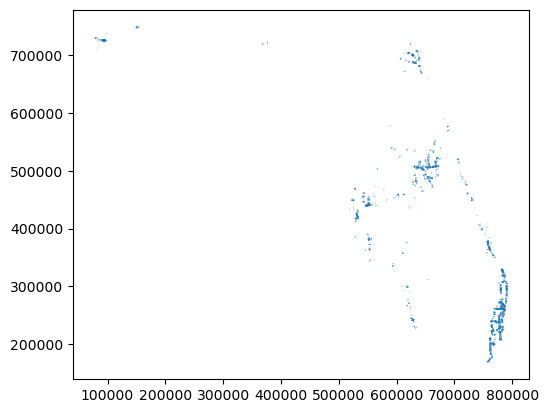

In [5]:
barriers.plot()

In [13]:
barriers.loc[:,["FM_ID", "ROADWAY", "FED_COUNTY", "TYPE", "FED_YRCON", "geometry"]].isna().mean()

FM_ID         0.000606
ROADWAY       0.000000
FED_COUNTY    0.000000
TYPE          0.000000
FED_YRCON     0.000000
geometry      0.000000
dtype: float64

In [14]:
barriers["TYPE"].value_counts()

TYPE
CONSTRUCTED BARRIERS    1059
RECOMMENDED BARRIERS     497
REMOVED BARRIERS          73
PRIVATE WALL              11
REPLACED BARRIERS         10
Name: count, dtype: int64

In [ ]:
# looks clean
barriers.query("TYPE == 'CONSTRUCTED BARRIERS'").FED_YRCON.value_counts().sort_index().iloc[[0,-1]]

FED_YRCON
1977    1
2023    9
Name: count, dtype: int64

In [ ]:
# to clean...
barriers.query("TYPE == 'RECOMMENDED BARRIERS'").FED_YRCON.value_counts()

FED_YRCON
9999    496
1995      1
Name: count, dtype: int64

In [ ]:
# to clean...
barriers.query("TYPE == 'REMOVED BARRIERS'").TBR_NOTE

52      DUPLICATE RECORD - REMOVED IN MARCH 2023 - MAI...
53      DUPLICATE RECORD - REMOVED IN MARCH 2023 - MAI...
67                                        REMOVED IN PD&E
68                                        REMOVED IN PD&E
69                                        REMOVED IN PD&E
                              ...                        
1458     NON-CONSTRUCTED RECORD - TYPE CHANGED MARCH 2022
1462     NON-CONSTRUCTED RECORD - TYPE CHANGED MARCH 2022
1463     NON-CONSTRUCTED RECORD - TYPE CHANGED MARCH 2022
1464     NON-CONSTRUCTED RECORD - TYPE CHANGED MARCH 2022
1582                 DUPLICATE RECORD - KEEPING GCID 1002
Name: TBR_NOTE, Length: 73, dtype: str

In [ ]:
# source: https://nces.ed.gov/programs/edge/geographic/schoollocations
schools = gpd.read_file("../../data/florida/schools/EDGE_GEOCODE_PUBLICSCH_2425/Shapefile_SCH/EDGE_GEOCODE_PUBLICSCH_2425.shp")
schools = schools.query("STATE=='FL'").to_crs(3087)
schools

,NCESSCH,LEAID,NAME,OPSTFIPS,STREET,CITY,STATE,ZIP,STFIP,CNTY,...,CBSA,NMCBSA,CBSATYPE,CSA,NMCSA,CD,SLDL,SLDU,SCHOOLYEAR,geometry
19568,120000207976,1200002,FLORIDA VIRTUAL ELEMENTARY SCHOOL,12,5422 CARRIER DR,ORLANDO,FL,32819,12,12095,...,36740,"Orlando-Kissimmee-Sanford, FL",1,422,"Orlando-Lakeland-Deltona, FL",1210,12041,12015,2024-2025,POINT (648911.772 497097.841)
19569,120000207982,1200002,FLORIDA VIRTUAL HIGH SCHOOL,12,5422 CARRIER DR,ORLANDO,FL,32819,12,12095,...,36740,"Orlando-Kissimmee-Sanford, FL",1,422,"Orlando-Lakeland-Deltona, FL",1210,12041,12015,2024-2025,POINT (648911.772 497097.841)
19570,120000208677,1200002,FLORIDA VIRTUAL MIDDLE SCHOOL,12,5422 CARRIER DR,ORLANDO,FL,32819,12,12095,...,36740,"Orlando-Kissimmee-Sanford, FL",1,422,"Orlando-Lakeland-Deltona, FL",1210,12041,12015,2024-2025,POINT (648911.772 497097.841)
19571,120003000002,1200030,CAROLYN BEATRICE PARKER ELEMENTARY,12,1912 NW 5TH AVE,GAINESVILLE,FL,32603,12,12001,...,23540,"Gainesville, FL",1,264,"Gainesville-Lake City, FL",1203,12022,12006,2024-2025,POINT (559611.221 628824.754)
19572,120003000003,1200030,STEPHEN FOSTER ELEMENTARY SCHOOL,12,3800 NW 6TH ST,GAINESVILLE,FL,32609,12,12001,...,23540,"Gainesville, FL",1,264,"Gainesville-Lake City, FL",1203,12021,12006,2024-2025,POINT (561184.595 632328.194)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23877,120201910838,1202019,TALLAHASSEE COLLEGIATE ACADEMY,12,444 APPLEYARD DR,TALLAHASSEE,FL,32304,12,12073,...,45220,"Tallahassee, FL",1,533,"Tallahassee-Bainbridge, FL-GA",1202,12008,12003,2024-2025,POINT (367339.567 715505.5)
23878,120202010841,1202020,THE COLLEGIATE SCHOOL AT FSU PC,12,2430 ST ANDREWS BLVD,PANAMA CITY,FL,32405,12,12005,...,37460,"Panama City-Panama City Beach, FL",1,N,N,1202,12006,12002,2024-2025,POINT (236473.594 688226.254)
23879,120202110844,1202021,FLORIDA SCHOLARS ACADEMY,12,2737 CENTERVIEW DRIVE,TALLAHASSEE,FL,32399,12,12073,...,45220,"Tallahassee, FL",1,533,"Tallahassee-Bainbridge, FL-GA",1202,12008,12003,2024-2025,POINT (377538.755 712468.126)
101074,590009000053,5900090,Miccosukee Indian School,59,US HWY 41 Mile Marker 37.5,Miami,FL,33194,12,12086,...,33100,"Miami-Fort Lauderdale-West Palm Beach, FL",1,370,"Miami-Port St. Lucie-Fort Lauderdale, FL",1228,12120,12040,2024-2025,POINT (720980.003 199347.81)


In [17]:
school_barrier_matrix = schools.geometry.apply(lambda x: barriers.distance(x))

In [22]:
school_barrier_matrix.apply(lambda x: (x < 1000).sum()).mean()

np.float64(1.2266666666666666)

0       1661.327880
1       1220.966148
2        466.560066
3        616.528281
4        475.946828
           ...     
1645     681.944325
1646     776.345230
1647     119.190383
1648     255.136998
1649     337.290904
Name: SHAPE_Length, Length: 1650, dtype: float64

In [21]:
school_barrier_matrix.apply(lambda x: (x < 1000).any()).mean()

np.float64(0.6284848484848485)

In [67]:
barriers.loc[(school_barrier_matrix < 1000).any(axis=0)].SHAPE_Length.mean()

np.float64(499.10019471946737)

In [68]:
barriers.loc[(school_barrier_matrix < 1000).any(axis=0)].SHAPE_Length.max()

np.float64(3345.194960180091)

In [50]:
np.where(
        school_barrier_matrix < 1000,
        np.ones_like(school_barrier_matrix),
        np.nan
        ) @ barriers.SHAPE_Length

array([nan, nan, nan, ..., nan, nan, nan], shape=(4312,))

In [ ]:
np.where(
        school_barrier_matrix < 1000,
        np.ones_like(school_barrier_matrix),
        np.nan
        ))

np.float64(2024.0)

In [60]:
(
    np.where(
        school_barrier_matrix < 1000,
        np.ones_like(school_barrier_matrix),
        np.nan
        ) @
    barriers.SHAPE_Length
    )

array([nan, nan, nan, ..., nan, nan, nan], shape=(4312,))